# Purpose

- Here I will explore the motivation for Optimal Transport methods.
- This means I will explore other methods for measuring distances between 2 distributions (or more generally, between 2 vectors) and their limitations, which led to the further development of OT
- The idea is always to connect to biology, such as in distances between cells via gene expression


# Import packages


In [39]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create data


## Coin flips


In [30]:
coin1 = [0.2, 0.7]
coin2 = [0.3, 0.3]
coin3 = [0.9, 0.6]

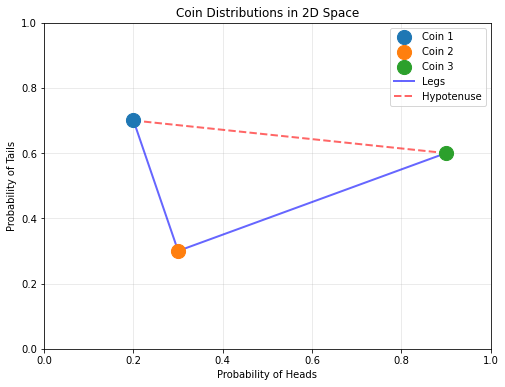

In [32]:
plt.figure(figsize=(8, 6))
# Plot points
plt.scatter([coin1[0]], [coin1[1]], s=200, label="Coin 1", alpha=1, zorder=3)
plt.scatter([coin2[0]], [coin2[1]], s=200, label="Coin 2", alpha=1, zorder=3)
plt.scatter([coin3[0]], [coin3[1]], s=200, label="Coin 3", alpha=1, zorder=3)

# Draw lines - legs in blue
plt.plot(
    [coin1[0], coin2[0]],
    [coin1[1], coin2[1]],
    "b-",
    linewidth=2,
    label="Legs",
    alpha=0.6,
)
plt.plot([coin2[0], coin3[0]], [coin2[1], coin3[1]], "b-", linewidth=2, alpha=0.6)

# Draw line - hypotenuse in red
plt.plot(
    [coin1[0], coin3[0]],
    [coin1[1], coin3[1]],
    "r--",
    linewidth=2,
    label="Hypotenuse",
    alpha=0.6,
)

plt.xlabel("Probability of Heads")
plt.ylabel("Probability of Tails")
plt.title("Coin Distributions in 2D Space")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

# Classical vector distances


## L1 distance (Manhattan)


In [33]:
l1_1vs2 = round(sum(abs(a - b) for a, b in zip(coin1, coin2)), 4)
l1_2vs1 = round(sum(abs(a - b) for a, b in zip(coin2, coin1)), 4)

display(l1_1vs2)
display(l1_2vs1)

0.5

0.5

- The L1 distance is symmetric


In [34]:
l1_1vs2 = round(sum(abs(a - b) for a, b in zip(coin1, coin2)), 4)
l1_2vs3 = round(sum(abs(a - b) for a, b in zip(coin2, coin3)), 4)
l1_1vs3 = round(sum(abs(a - b) for a, b in zip(coin1, coin3)), 4)

print(l1_1vs2)
print(l1_2vs3)
print(f"Sum of the 'legs': {l1_1vs2 + l1_2vs3}")
print(f"Hypotenuse: {l1_1vs3}")

0.5
0.9
Sum of the 'legs': 1.4
Hypotenuse: 0.8


- Satisfies triangle inequality (of course this does not prove it, just an example)


## L2 distance (Euclidean)


In [41]:
l2_1vs2 = round(math.sqrt(sum((a - b) ** 2 for a, b in zip(coin1, coin2))), 4)
l2_2vs1 = round(math.sqrt(sum((a - b) ** 2 for a, b in zip(coin2, coin1))), 4)

display(l2_1vs2)
display(l2_2vs1)

0.4123

0.4123

- The L2 distance is also symmetric


In [40]:
l2_1vs2 = round(math.sqrt(sum((a - b) ** 2 for a, b in zip(coin1, coin2))), 4)
l2_2vs3 = round(math.sqrt(sum((a - b) ** 2 for a, b in zip(coin2, coin3))), 4)
l2_1vs3 = round(math.sqrt(sum((a - b) ** 2 for a, b in zip(coin1, coin3))), 4)

print(l2_1vs2)
print(l2_2vs3)
print(f"Sum of the 'legs': {l2_1vs2 + l2_2vs3}")
print(f"Hypotenuse: {l2_1vs3}")

0.4123
0.6708
Sum of the 'legs': 1.0831
Hypotenuse: 0.7071


- Satisfies triangle inequality


## Cosine distance


# Information-theoretic divergences


## Kullback-Leibler divergence


In [ ]:
from scipy.stats import entropy


def compute_kl_divergence_package(p, q):
    """
    Compute the Kullback-Leibler divergence D_KL(P || Q) using scipy.

    Parameters:
    p (array-like): First probability distribution.
    q (array-like): Second probability distribution.

    Returns:
    float: The KL divergence value.
    """
    return entropy(p, q)


def compute_kl_divergence(p, q, epsilon=1e-10):
    """
    Compute the Kullback-Leibler divergence D_KL(P || Q) between two distributions.

    Parameters:
    p (array-like): First probability distribution.
    q (array-like): Second probability distribution.
    epsilon (float): Small value to avoid log(0).

    Returns:
    float: The KL divergence value.
    """
    p = np.asarray(p) + epsilon
    q = np.asarray(q) + epsilon
    return np.sum(p * np.log(p / q))

In [75]:
kl_1vs2 = compute_kl_divergence(coin1, coin2)
kl_2vs1 = compute_kl_divergence(coin2, coin1)

print(f"KL Divergence D_KL(Coin1 || Coin2): {kl_1vs2:.2f}")
print(f"KL Divergence D_KL(Coin2 || Coin1): {kl_2vs1:.2f}")

KL Divergence D_KL(Coin1 || Coin2): 0.19
KL Divergence D_KL(Coin2 || Coin1): 0.22


In [74]:
kl_1vs2 = compute_kl_divergence_package(coin1, coin2)
kl_2vs1 = compute_kl_divergence_package(coin2, coin1)

print(f"KL Divergence D_KL(Coin1 || Coin2): {kl_1vs2:.2f}")
print(f"KL Divergence D_KL(Coin2 || Coin1): {kl_2vs1:.2f}")

KL Divergence D_KL(Coin1 || Coin2): 0.19
KL Divergence D_KL(Coin2 || Coin1): 0.22


- KL is not symmetric


- The Scipy package scales the distribution to sum up to 1


In [70]:
kl_1vs2 = compute_kl_divergence_package(coin1, coin2)
kl_2vs1 = compute_kl_divergence_package(coin2, coin1)
kl_1vs3 = compute_kl_divergence_package(coin1, coin3)
kl_2vs3 = compute_kl_divergence_package(coin2, coin3)

print(f"KL Divergence D_KL(Coin1 || Coin2): {kl_1vs2:.2f}")
print(f"KL Divergence D_KL(Coin2 || Coin1): {kl_2vs1:.2f}")
print(f"KL Divergence D_KL(Coin1 || Coin3): {kl_1vs3:.2f}")
print(f"KL Divergence D_KL(Coin2 || Coin3): {kl_2vs3:.2f}")

KL Divergence D_KL(Coin1 || Coin2): 0.19
KL Divergence D_KL(Coin2 || Coin1): 0.22
KL Divergence D_KL(Coin1 || Coin3): 1.36
KL Divergence D_KL(Coin2 || Coin3): 0.51


- Does not hold triangle inequality: travelling from Coin1 to Coin2 and then to Coin3 should be greater or equal than directly from Coin1 to Coin3


## Jensen–Shannon (JS) divergence


# Optimal transport–based distances


## Wasserstein distance


In [84]:
from scipy.stats import wasserstein_distance


def compute_wasserstein_distance_package(p, q):
    """
    Compute the Wasserstein distance (Earth Mover's Distance) between two distributions.

    Parameters:
    p (array-like): First probability distribution.
    q (array-like): Second probability distribution.

    Returns:
    float: The Wasserstein distance value.
    """
    return wasserstein_distance(p, q)


def compute_wasserstein_distance(p, q):
    """
    Compute the 1D Wasserstein distance (Earth Mover's Distance) between two distributions.

    Parameters:
    p (array-like): First probability distribution.
    q (array-like): Second probability distribution.

    Returns:
    float: The Wasserstein distance value.
    """
    p_sorted = np.sort(p)
    q_sorted = np.sort(q)
    return np.sum(np.abs(np.cumsum(p_sorted) - np.cumsum(q_sorted)))

In [73]:
print(f"Coin 1: {coin1}")
print(f"Coin 2: {coin2}")
print(f"Coin 3: {coin3}")

Coin 1: [0.2, 0.8]
Coin 2: [0.5, 0.5]
Coin 3: [0.9, 0.1]


In [79]:
kl_1vs2 = compute_wasserstein_distance(coin1, coin2)
kl_2vs1 = compute_wasserstein_distance(coin2, coin1)

print(f"Wasserstein Distance D_W(Coin1 || Coin2): {kl_1vs2:.2f}")
print(f"Wasserstein Distance D_W(Coin2 || Coin1): {kl_2vs1:.2f}")

Wasserstein Distance D_W(Coin1 || Coin2): 0.30
Wasserstein Distance D_W(Coin2 || Coin1): 0.30


In [78]:
kl_1vs2 = compute_wasserstein_distance_package(coin1, coin2)
kl_2vs1 = compute_wasserstein_distance_package(coin2, coin1)

print(f"Wasserstein Distance D_W(Coin1 || Coin2): {kl_1vs2:.2f}")
print(f"Wasserstein Distance D_W(Coin2 || Coin1): {kl_2vs1:.2f}")

Wasserstein Distance D_W(Coin1 || Coin2): 0.30
Wasserstein Distance D_W(Coin2 || Coin1): 0.30


- Wasserstein is symmetric


In [83]:
wd_1vs2 = compute_wasserstein_distance_package(coin1, coin2)
wd_2vs3 = compute_wasserstein_distance_package(coin2, coin3)
wd_1vs3 = compute_wasserstein_distance_package(coin1, coin3)

print(f"Wasserstein Distance D_W(Coin1 || Coin2): {wd_1vs2:.2f}")
print(f"Wasserstein Distance D_W(Coin2 || Coin3): {wd_2vs3:.2f}")
print(f"Wasserstein Distance D_W(Coin1 || Coin3): {wd_1vs3:.2f}")

Wasserstein Distance D_W(Coin1 || Coin2): 0.30
Wasserstein Distance D_W(Coin2 || Coin3): 0.40
Wasserstein Distance D_W(Coin1 || Coin3): 0.10


- Satisfies the triangle inequality
